Assignment 10 Name: Shlok Nikam PRN: 12414145 Batch: 2 Division: D Branch: CSE(AI)


10. Assignment on Regression technique.

Download temperature data from the link below.

https://www.kaggle.com/venky73/temperaturesof-india?select=temperatures.csv

This data consists of temperatures of INDIA averaging the temperatures of all places month wise. Temperatures values are recorded in CELSIUS

Apply Linear Regression using a suitable library function and predict the Month-wise temperature.
Assess the performance of regression models using MSE, MAE and R-Square   
metrics
Visualize a simple regression model.


## Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully.')

Libraries imported successfully.


## Step 2: Load Dataset

In [ ]:
df = pd.read_csv('temperatures.csv')
print('Shape:', df.shape)
df.head()

Shape: (117, 18)


,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
0,1901,22.40,24.14,29.07,31.91,33.41,33.18,31.21,30.39,30.47,29.97,27.31,24.49,28.96,23.27,31.46,31.27,27.25
1,1902,24.93,26.58,29.77,31.78,33.73,32.91,30.92,30.73,29.80,29.12,26.31,24.04,29.22,25.75,31.76,31.09,26.49
2,1903,23.44,25.03,27.83,31.39,32.91,33.00,31.34,29.98,29.85,29.04,26.08,23.65,28.47,24.24,30.71,30.92,26.26
3,1904,22.50,24.73,28.21,32.02,32.64,32.07,30.36,30.09,30.04,29.20,26.36,23.63,28.49,23.62,30.95,30.66,26.40
4,1905,22.00,22.83,26.68,30.01,33.32,33.25,31.44,30.68,30.12,30.67,27.52,23.82,28.30,22.25,30.00,31.33,26.57


## Step 3: Data Exploration

In [ ]:
print('Dataset Info:')
df.info()
print('\nMissing Values:')
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   YEAR     117 non-null    int64  
 1   JAN      117 non-null    float64
 2   FEB      117 non-null    float64
 3   MAR      117 non-null    float64
 4   APR      117 non-null    float64
 5   MAY      117 non-null    float64
 6   JUN      117 non-null    float64
 7   JUL      117 non-null    float64
 8   AUG      117 non-null    float64
 9   SEP      117 non-null    float64
 10  OCT      117 non-null    float64
 11  NOV      117 non-null    float64
 12  DEC      117 non-null    float64
 13  ANNUAL   117 non-null    float64
 14  JAN-FEB  117 non-null    float64
 15  MAR-MAY  117 non-null    float64
 16  JUN-SEP  117 non-null    float64
 17  OCT-DEC  117 non-null    float64
dtypes: float64(17), int64(1)
memory usage: 16.6 KB

Missing Values:
YEAR       0
JAN        0
FEB        0
MAR        0


In [ ]:
print('Statistical Summary:')
df.describe()

Statistical Summary:


,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JAN-FEB,MAR-MAY,JUN-SEP,OCT-DEC
count,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000,117.000000
mean,1959.000000,23.687436,25.597863,29.085983,31.975812,33.565299,32.774274,31.035897,30.507692,30.486752,29.766581,27.285470,24.608291,29.181368,24.629573,31.517607,31.198205,27.208120
std,33.919021,0.834588,1.150757,1.068451,0.889478,0.724905,0.633132,0.468818,0.476312,0.544295,0.705492,0.714518,0.782644,0.555555,0.911239,0.740585,0.420508,0.672003
min,1901.000000,22.000000,22.830000,26.680000,30.010000,31.930000,31.100000,29.760000,29.310000,29.070000,27.900000,25.700000,23.020000,28.110000,22.250000,29.920000,30.240000,25.740000
25%,1930.000000,23.100000,24.780000,28.370000,31.460000,33.110000,32.340000,30.740000,30.180000,30.120000,29.380000,26.790000,24.040000,28.760000,24.110000,31.040000,30.920000,26.700000
50%,1959.000000,23.680000,25.480000,29.040000,31.950000,33.510000,32.730000,31.000000,30.540000,30.520000,29.780000,27.300000,24.660000,29.090000,24.530000,31.470000,31.190000,27.210000
75%,1988.000000,24.180000,26.310000,29.610000,32.420000,34.030000,33.180000,31.330000,30.760000,30.810000,30.170000,27.720000,25.110000,29.470000,25.150000,31.890000,31.400000,27.610000
max,2017.000000,26.940000,29.720000,32.620000,35.380000,35.840000,34.480000,32.760000,31.840000,32.220000,32.290000,30.110000,28.010000,31.630000,28.330000,34.570000,32.410000,30.030000


## Step 4: Data Pre-Processing
- Keep only the 12 monthly columns (JAN to DEC).
- Melt the dataframe so each row has `Month` (1–12) and `Temperature`.
- This creates a long-format dataset suitable for regression.

In [ ]:
# Keep only month columns
month_cols = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
df_months = df[['YEAR'] + month_cols].copy()

# Melt to long format
df_melted = df_months.melt(id_vars='YEAR', value_vars=month_cols,
                            var_name='Month_Name', value_name='Temperature')

# Map month names to numbers
month_map = {'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
             'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12}
df_melted['Month'] = df_melted['Month_Name'].map(month_map)

# Drop missing values if any
df_melted.dropna(inplace=True)

print('Processed dataset shape:', df_melted.shape)
df_melted.head(12)

Processed dataset shape: (1404, 4)


,YEAR,Month_Name,Temperature,Month
0,1901,JAN,22.40,1
1,1902,JAN,24.93,1
2,1903,JAN,23.44,1
3,1904,JAN,22.50,1
4,1905,JAN,22.00,1
5,1906,JAN,22.28,1
6,1907,JAN,24.46,1
7,1908,JAN,23.57,1
8,1909,JAN,22.67,1
9,1910,JAN,23.24,1


In [ ]:
# Average temperature per month across all years
monthly_avg = df_melted.groupby('Month')['Temperature'].mean().reset_index()
monthly_avg.columns = ['Month', 'Avg_Temperature']
print('Average Temperature per Month:')
print(monthly_avg)

Average Temperature per Month:
    Month  Avg_Temperature
0       1        23.687436
1       2        25.597863
2       3        29.085983
3       4        31.975812
4       5        33.565299
5       6        32.774274
6       7        31.035897
7       8        30.507692
8       9        30.486752
9      10        29.766581
10     11        27.285470
11     12        24.608291


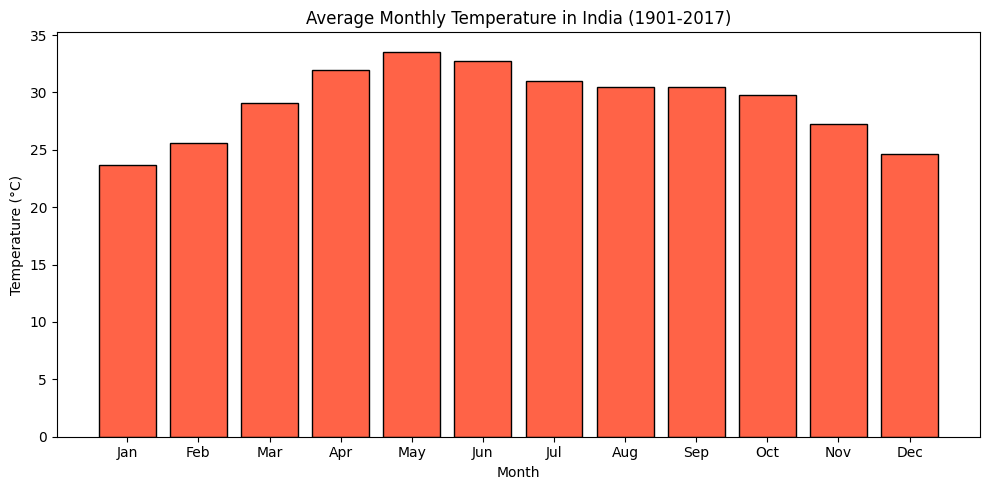

In [ ]:
# Bar plot of monthly average temperatures
plt.figure(figsize=(10, 5))
plt.bar(monthly_avg['Month'], monthly_avg['Avg_Temperature'], color='tomato', edgecolor='black')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Average Monthly Temperature in India (1901-2017)')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

## Step 5: Train-Test Split

In [ ]:
X = monthly_avg[['Month']]
y = monthly_avg['Avg_Temperature']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing  samples: {X_test.shape[0]}')

Training samples: 9
Testing  samples: 3


## Step 6: Apply Linear Regression

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f'Intercept  : {model.intercept_:.4f}')
print(f'Coefficient: {model.coef_[0]:.4f}')
print(f'\nEquation: Temperature = {model.intercept_:.2f} + {model.coef_[0]:.2f} * Month')

Intercept  : 31.2053
Coefficient: -0.2002

Equation: Temperature = 31.21 + -0.20 * Month


## Step 7: Model Evaluation (MSE, MAE, R²)

In [ ]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print('===== Model Evaluation Metrics =====')
print(f'Mean Squared Error  (MSE) : {mse:.4f}')
print(f'Mean Absolute Error (MAE) : {mae:.4f}')
print(f'R-Squared           (R²)  : {r2:.4f}')

===== Model Evaluation Metrics =====
Mean Squared Error  (MSE) : 18.9388
Mean Absolute Error (MAE) : 3.1995
R-Squared           (R²)  : -2.0406


## Step 8: Visualize the Regression Model

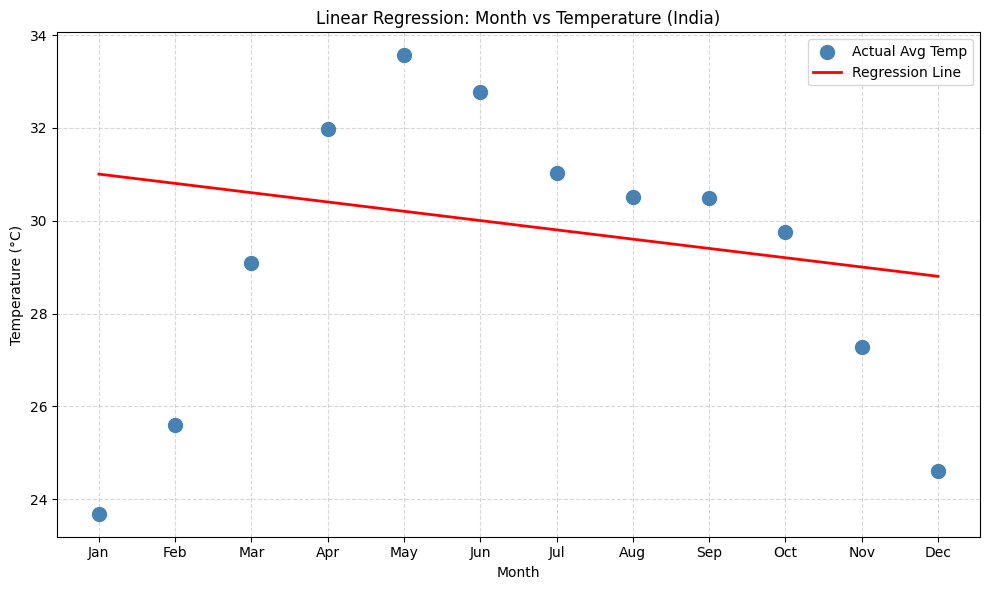

In [ ]:
# Predict across all 12 months for regression line
X_all = pd.DataFrame({'Month': range(1, 13)})
y_line = model.predict(X_all)

plt.figure(figsize=(10, 6))

# Scatter: actual average temperatures
plt.scatter(monthly_avg['Month'], monthly_avg['Avg_Temperature'],
            color='steelblue', s=100, zorder=5, label='Actual Avg Temp')

# Regression line
plt.plot(X_all['Month'], y_line, color='red', linewidth=2, label='Regression Line')

plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Linear Regression: Month vs Temperature (India)')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

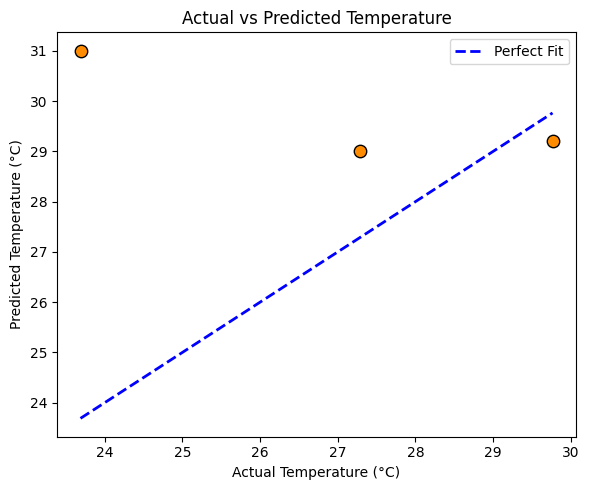

In [ ]:
# Actual vs Predicted (test set)
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, color='darkorange', edgecolors='black', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', lw=2, label='Perfect Fit')
plt.title('Actual vs Predicted Temperature')
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

## Step 9: Predict Temperature for Any Month

In [ ]:
# Predict temperature for all 12 months
months = pd.DataFrame({'Month': range(1, 13)})
predictions = model.predict(months)

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
result_df = pd.DataFrame({'Month': month_names, 'Predicted Temperature (°C)': predictions.round(2)})
print('Month-wise Predicted Temperatures:')
print(result_df.to_string(index=False))

Month-wise Predicted Temperatures:
Month  Predicted Temperature (°C)
  Jan                       31.01
  Feb                       30.80
  Mar                       30.60
  Apr                       30.40
  May                       30.20
  Jun                       30.00
  Jul                       29.80
  Aug                       29.60
  Sep                       29.40
  Oct                       29.20
  Nov                       29.00
  Dec                       28.80
